# 04 — Análise do Grafo e Detecção de Comunidades

Calculamos métricas de centralidade e detectamos comunidades com o algoritmo de Louvain.
Execute os notebooks `01_coleta` e `03_grafo` antes deste.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from pathlib import Path

from src.fetch import carregar_raw
from src.graph import construir_grafo_coautoria, filtrar_grafo, maior_componente
from src.metrics import calcular_centralidades, detectar_comunidades, resumo_rede

FIGURES = Path('../reports/figures')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

works = carregar_raw('works_ufms_cs')
G = maior_componente(filtrar_grafo(construir_grafo_coautoria(works), min_degree=2))
print(resumo_rede(G))

{'nodes': 417, 'edges': 2037, 'density': 0.0235, 'avg_degree': 9.77, 'components': 1, 'avg_clustering': 0.0574, 'largest_component_size': 417}


## 1. Métricas de Centralidade

In [2]:
df = calcular_centralidades(G)
df.to_csv(PROCESSED / 'centralidades.csv', index=False)
print(f'Exportado: {PROCESSED}/centralidades.csv')
df.head(15)

Exportado: ../data/processed/centralidades.csv


,node,degree,betweenness,eigenvector,clustering,degree_raw
0,Edson Takashi Matsubara,0.108173,0.485628,1.152593e-01,0.013554,45
1,Edson Antonio Batista,0.069712,0.331143,5.048073e-02,0.017152,29
2,Awdren Fontão,0.100962,0.227518,3.276595e-03,0.009028,42
3,José Marcato,0.245192,0.173928,5.393955e-01,0.008622,102
4,Ricardo Santos,0.048077,0.156519,1.370433e-03,0.016958,20
5,Henrique Mongelli,0.033654,0.155248,2.864055e-03,0.020088,14
6,Wesley Nunes Gonçalves,0.199519,0.144217,4.872495e-01,0.010767,83
7,Edson N. Cáceres,0.021635,0.126726,1.381915e-04,0.025617,9
8,Thiago Rangel Rodrigues,0.125000,0.123360,3.843171e-02,0.023216,52
9,Doglas W. Sorgatto,0.007212,0.108990,2.969841e-06,0.045240,3


## 2. Distribuição de Centralidade

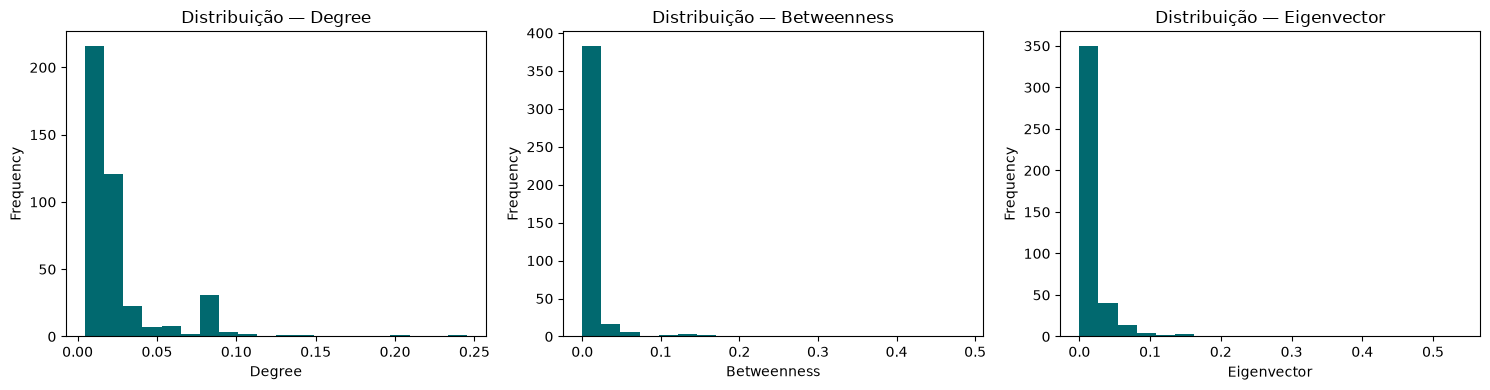

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(axes,
    ['degree', 'betweenness', 'eigenvector'],
    ['Degree', 'Betweenness', 'Eigenvector']
):
    df[col].plot(kind='hist', bins=20, color='#01696f', ax=ax)
    ax.set_title(f'Distribuição — {label}', fontsize=12)
    ax.set_xlabel(label)

plt.tight_layout()
plt.savefig(FIGURES / 'distribuicao_centralidades.png', dpi=150)
plt.show()

## 3. Detecção de Comunidades (Louvain)

In [4]:
comunidades = detectar_comunidades(G)
nx.set_node_attributes(G, comunidades, 'community')

n_com = len(set(comunidades.values()))
print(f'Comunidades detectadas: {n_com}')

# Distribuição de tamanho das comunidades
tamanhos = pd.Series(comunidades.values()).value_counts().sort_index()
print(tamanhos.to_string())

Comunidades detectadas: 13
0     31
1     16
2      7
3     43
4     19
5     53
6      7
7     25
8     14
9     43
10    31
11    93
12    35


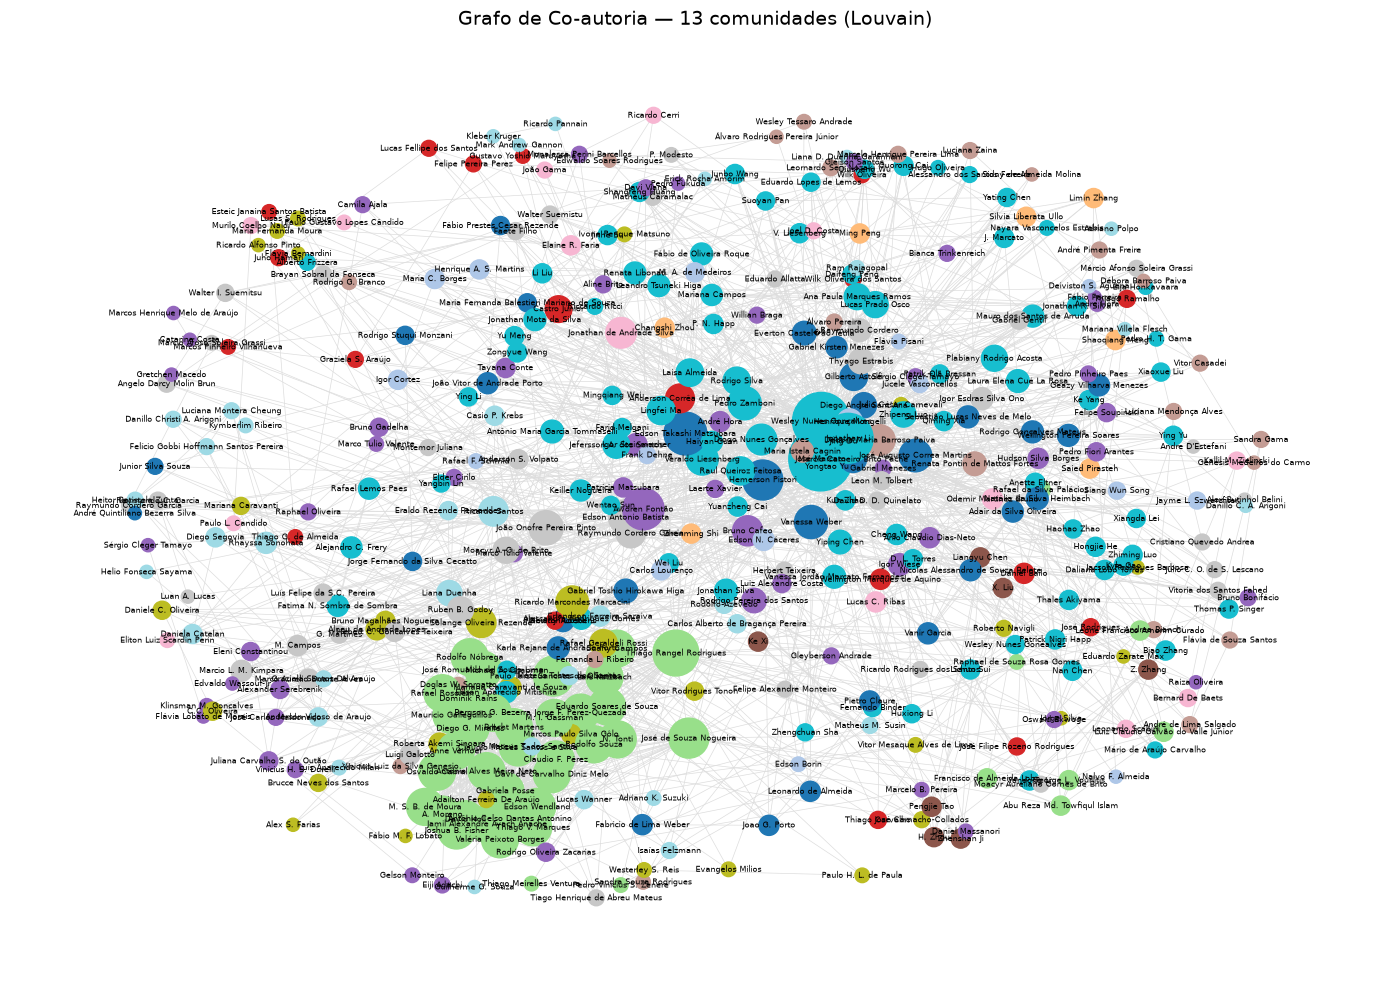

In [5]:
pos = nx.spring_layout(G, seed=42, k=0.6)
cores = [comunidades[n] for n in G.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx(
    G, pos=pos,
    node_color=cores, cmap=cm.tab20,
    node_size=[G.degree(n) * 20 + 50 for n in G.nodes()],
    edge_color='#dddddd', width=0.5,
    font_size=6, with_labels=True,
)
plt.title(f'Grafo de Co-autoria — {n_com} comunidades (Louvain)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURES / 'comunidades.png', dpi=150)
plt.show()

## 4. Exportar Grafo como CSV de Arestas

In [6]:
edges_df = pd.DataFrame([
    {
        'source': u,
        'target': v,
        'weight': d.get('weight', 1),
        'community_source': comunidades.get(u, -1),
        'community_target': comunidades.get(v, -1),
    }
    for u, v, d in G.edges(data=True)
])

edges_df.to_csv(PROCESSED / 'arestas_coautoria.csv', index=False)
print(f'{len(edges_df)} arestas exportadas')
edges_df.head()

2037 arestas exportadas


,source,target,weight,community_source,community_target
0,Gilberto Astolfi,Diego André Sant’Ana,2,0,0
1,Gilberto Astolfi,Marcio Carneiro Brito Pache,2,0,0
2,Gilberto Astolfi,José Augusto Correa Martins,1,0,0
3,Gilberto Astolfi,Wellington Pereira Soares,1,0,0
4,Gilberto Astolfi,Sebastião Lucas Neves de Melo,1,0,0


## 5. Top Brokers (Alta Betweenness)

In [7]:
print('Pesquisadores com maior betweenness (pontes entre grupos):\n')
print(df[['node', 'degree_raw', 'betweenness', 'eigenvector']].head(10).to_string(index=False))

Pesquisadores com maior betweenness (pontes entre grupos):

                   node  degree_raw  betweenness  eigenvector
Edson Takashi Matsubara          45     0.485628     0.115259
  Edson Antonio Batista          29     0.331143     0.050481
          Awdren Fontão          42     0.227518     0.003277
           José Marcato         102     0.173928     0.539396
         Ricardo Santos          20     0.156519     0.001370
      Henrique Mongelli          14     0.155248     0.002864
 Wesley Nunes Gonçalves          83     0.144217     0.487250
       Edson N. Cáceres           9     0.126726     0.000138
Thiago Rangel Rodrigues          52     0.123360     0.038432
     Doglas W. Sorgatto           3     0.108990     0.000003
